# Lab 4
Leonid Zinatullin

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann as kB

import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType
from nidaqmx.stream_readers import AnalogMultiChannelReader
from nidaqmx.stream_writers import AnalogSingleChannelWriter

import time

## Task 1

In [2]:
def JN_noise(R, T, df):
    return np.sqrt(4 * kB * T * R * df)

print(JN_noise(1e4, 297, 450e3), "V Hz^-0.5")

8.591245284590588e-06 V Hz^-0.5


## Task 2.1

peak-to-peak voltage: 0.0 V
mean voltage: -0.21345575440574058 V
RMS noise: 2.7755575615628914e-17 V


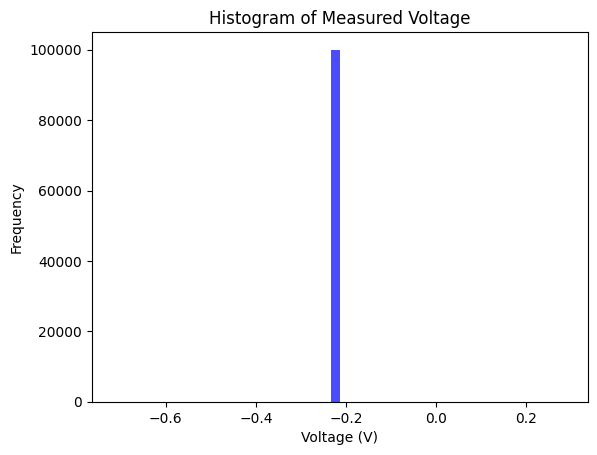

In [5]:
import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType

device_name = "/Dev5"
duration = 10 # seconds
rate = 10000 # samples per second
window_size = duration * rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-0.2,
        max_val=0.2
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=window_size
    )

    data = task.read(number_of_samples_per_channel=window_size)
    data = np.array(data)
print("peak-to-peak voltage:", np.ptp(data), "V")
print("mean voltage:", np.mean(data), "V")
print("RMS noise:", np.sqrt(np.mean(np.square(data - np.mean(data)))), "V")

#histogram
plt.hist(data, bins=50, color='blue', alpha=0.7)    
plt.title('Histogram of Measured Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.show()

| Impedance | DAQ range | Mean Value | Noise level |  | Brief description on any noticeable characteristics |
| :--- | :--- | :--- | :--- | :--- | :--- |
| $\Omega$ | [土 V] | V      | [V p-p] | [V rms] |  |
| 0 (shorted) |  0.2| 3.94e-5| 1.98e-4 | 3.35e-5|  random cutouts (probably quantisation)|
| 1 k         |  0.2| 3.58e-5| 3.03e-4 | 3.42e-5 |  |
| 1 M         |  0.2|-1.42e-5|  8.24e-3| 1.59e-3 |  Weird double hump distribution|
| $\infty$ (open) | 0.2|  -0.213| 0|  2.77e-27|  Histogram is very thin|

1 MOhm noise

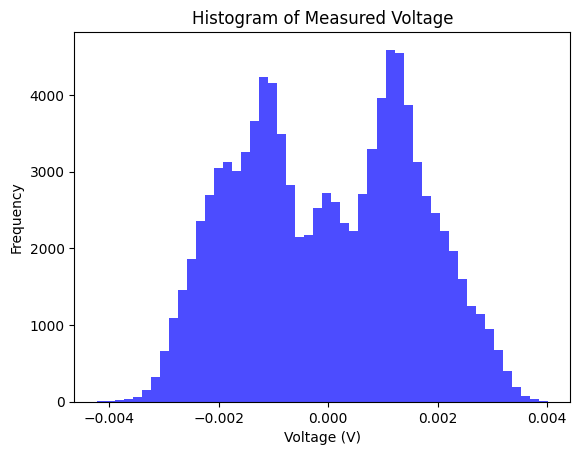

## Task 2.2

peak-to-peak voltage: 0.0001185730629403403 V
mean voltage: 4.575484362731849e-05 V
RMS noise: 1.6477019176778694e-05 V


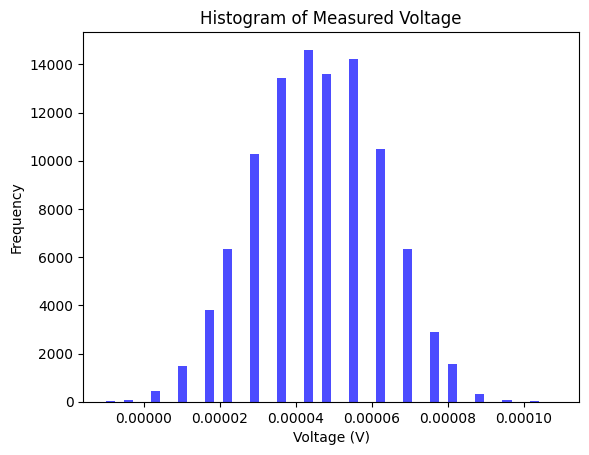

In [9]:
import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType

device_name = "/Dev5"
duration = 10 # seconds
rate = 10000 # samples per second
window_size = duration * rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.DIFF,
        min_val=-0.2,
        max_val=0.2
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=window_size
    )

    data = task.read(number_of_samples_per_channel=window_size)
    data = np.array(data)
print("peak-to-peak voltage:", np.ptp(data), "V")
print("mean voltage:", np.mean(data), "V")
print("RMS noise:", np.sqrt(np.mean(np.square(data - np.mean(data)))), "V")

#histogram
plt.hist(data, bins=50, color='blue', alpha=0.7)    
plt.title('Histogram of Measured Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.show()

| DAQ mode     | DAQ range           | Mean Value | Noise level           |                       |
|--------------|---------------------|------------|-----------------------|-----------------------|
|              | $[ \pm \mathrm{V}]$ | V          | $[\mathrm{V}$ p-p $]$ | $[\mathrm{V}$ rms $]$ |
| RSE (Al0)    | 0.2                 | 3.94e-5    | 1.98e-4               | 3.35e-5               |
| RSE (Al8)    | 0.2                 | 5.96e-5    | 1.71e-4               | 2.83e-5               |
| Differential | 0.2                 | 4.58e-5    | 1.19e-4               | 1.65e-5               |

Q: Based on the results, what can you say about the noise in the system?

A: Noise of the combined system is lower

Q: Which configuration yielded the best result and why?

A: The best was combined. Reason being the systematic noise is more or less the same (induced currents into wires), therefore it is cancelled out. 

# Task 3


In [8]:
import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType

peak-to-peak voltage: 0.0002172891105981802 V
mean voltage: 3.2048296126326845e-05 V
RMS noise: 3.135593933407816e-05 V


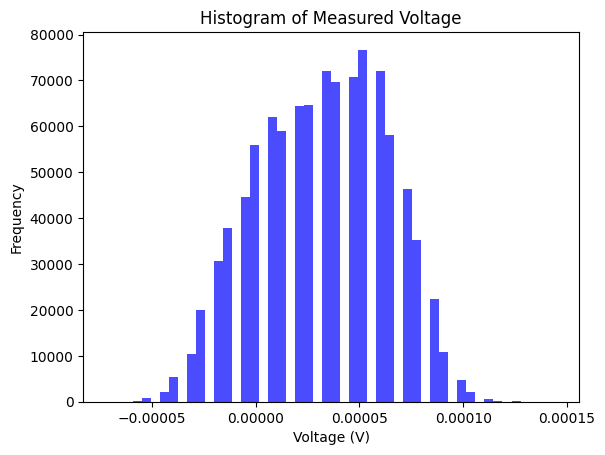

: 

In [ ]:


device_name = "/Dev6"
duration = 10 # seconds
rate = 100000 # samples per second
window_size = duration * rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-0.2,
        max_val=0.2
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=window_size
    )

    data = task.read(number_of_samples_per_channel=window_size)
    data = np.array(data)
print("peak-to-peak voltage:", np.ptp(data), "V")
print("mean voltage:", np.mean(data), "V")
print("RMS noise:", np.sqrt(np.mean(np.square(data - np.mean(data)))), "V")

#histogram
plt.hist(data, bins=50, color='blue', alpha=0.7)    
plt.title('Histogram of Measured Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
JN_noise(1e4, 297, 450e3)
#Fc = 1 / 2πRC
C = np.array([1e-9, 10e-9, 100e-9, 1e-6])
R = 1e3

def filter_cutoff(R, C):
    return 1 / (2 * np.pi * R * C)

for c in C:
    print("Cutoff frequency for C =", c, f"F: {filter_cutoff(R, c):.4} Hz")


Cutoff frequency for C = 1e-09 F: 1.592e+05 Hz
Cutoff frequency for C = 1e-08 F: 1.592e+04 Hz
Cutoff frequency for C = 1e-07 F: 1.592e+03 Hz
Cutoff frequency for C = 1e-06 F: 159.2 Hz


### 1nF
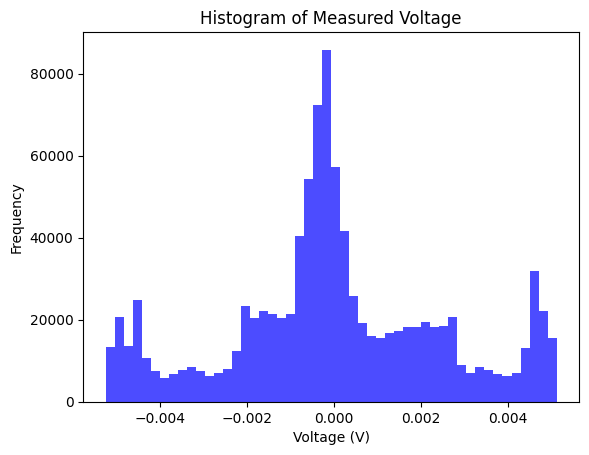
### 10 nF
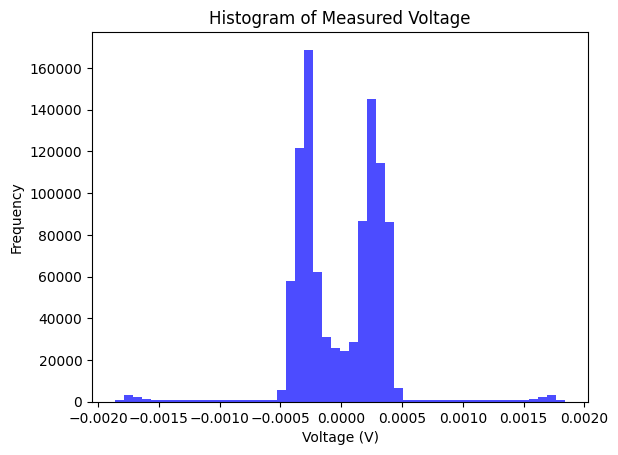
### 1uF
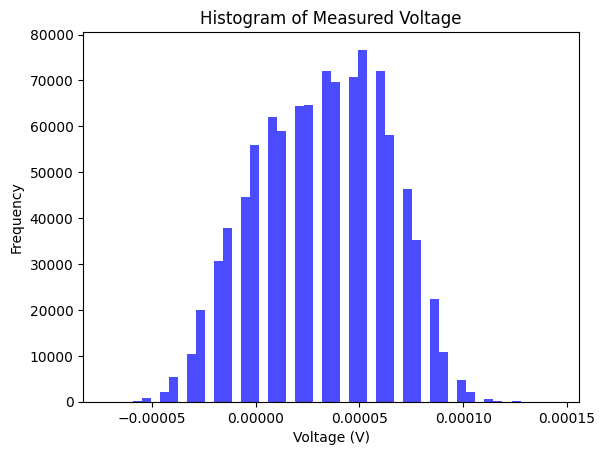

| Simulated sensor impedance | Filter R | Filter C | Calculated filter cutoff | Noise level |          | Brief description on any noticeable characteristics |
|----------------------------|----------|----------|--------------------------|-------------|----------|-----------------------------------------------------|
| $\Omega$                   | $\Omega$ | F        | Hz                       | [V p-p]     | [V rms]  |                                                     |
| 1 M                        | 1 k      | 1 n      | 159200                   | 0.010       | 0.00249  | Some wide sides                                     |
| 1 M                        | 1 k      | 10 n     | 15920                    | 0.0037      | 0.00038  | Weird double hump                                   |
| 1 M                        | 1 k      | 100 n    | 1592                     | 0.0011      | 0.000105 | Relatively normal                                   |
| 1 M                        | 1 k      | 1 u      | 159.2                    | 0.00022    | 0.000031 |  Quantisation noise                                     |

# Task 4

In [1]:
import time
import numpy as np
import plotly.graph_objects as go
from IPython.display import display, update_display

import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType

device_name = "/Dev7"

fs = 5_000 # samples per second
read_chunk = 2048
nfft = 1024
hop = 256
max_cols = 250
fmax_show = 1000

win = np.hanning(nfft).astype(np.float32)
freq = np.fft.rfftfreq(nfft, d=1/fs)
keep = freq <= fmax_show
freq = freq[keep]

Sbuf = np.full((freq.size, max_cols), -120.0, dtype=np.float32)

fig = go.FigureWidget(data=[go.Heatmap(z=Sbuf, x=np.arange(max_cols), y=freq, colorscale="Viridis")])
fig.update_layout(title="Live Spectrogram (0–1 kHz)", height=500, xaxis_title="Time (frames)", yaxis_title="Hz")

display_id = "spec"
display(fig, display_id=display_id)

ring = np.zeros(nfft, dtype=np.float32)
ring_fill = 0

def push_samples(x):
    global ring, ring_fill
    i = 0
    while i < len(x):
        take = min(len(x) - i, nfft - ring_fill)
        ring[ring_fill:ring_fill+take] = x[i:i+take]
        ring_fill += take
        i += take

        if ring_fill == nfft:
            frame = ring * win
            mag = np.abs(np.fft.rfft(frame)).astype(np.float32)[keep]
            yield 20 * np.log10(mag + 1e-12)

            ring[:-hop] = ring[hop:]
            ring_fill = nfft - hop

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-0.2, max_val=0.2
    )
    task.timing.cfg_samp_clk_timing(
        rate=fs,
        sample_mode=AcquisitionType.CONTINUOUS,
        samps_per_chan=read_chunk
    )
    task.start()

    try:
        last_ui = time.time()
        while True:
            x = np.asarray(task.read(number_of_samples_per_channel=read_chunk), dtype=np.float32)

            updated = 0
            for col in push_samples(x):
                Sbuf = np.roll(Sbuf, -1, axis=1)
                Sbuf[:, -1] = col
                updated += 1

            # Throttle UI updates (important in VS Code)
            if updated and (time.time() - last_ui) > 0.05:   # ~20 FPS max
                fig.data[0].z = Sbuf
                update_display(fig, display_id=display_id)
                last_ui = time.time()

            time.sleep(0.001)
    except KeyboardInterrupt:
        pass


FigureWidget({
    'data': [{'colorscale': [[0.0, '#440154'], [0.1111111111111111, '#482878'],
                             [0.2222222222222222, '#3e4989'], [0.3333333333333333,
                             '#31688e'], [0.4444444444444444, '#26828e'],
                             [0.5555555555555556, '#1f9e89'], [0.6666666666666666,
                             '#35b779'], [0.7777777777777778, '#6ece58'],
                             [0.8888888888888888, '#b5de2b'], [1.0, '#fde725']],
              'type': 'heatmap',
              'uid': '7c700f6f-ea4e-42e0-a801-eae03e4658b4',
              'x': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... '8A8ADxAPIA8wD0APUA9gD3APgA+QA='),
                    'dtype': 'i2'},
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAIgTQAAAAAAAiC' ... 'AAoNKOQAAAAACw+Y5AAAAAAMAgj0A='),
                    'dtype': 'f8'},
              'z': {'bdata': ('qVPlwWN/AMLi4OXBRtLJwZhBHMI22b' ... 'JKAJvC68eUwkN5dsLaUYDCpGJvwg=='),
                    'dtype': 'f4',
   

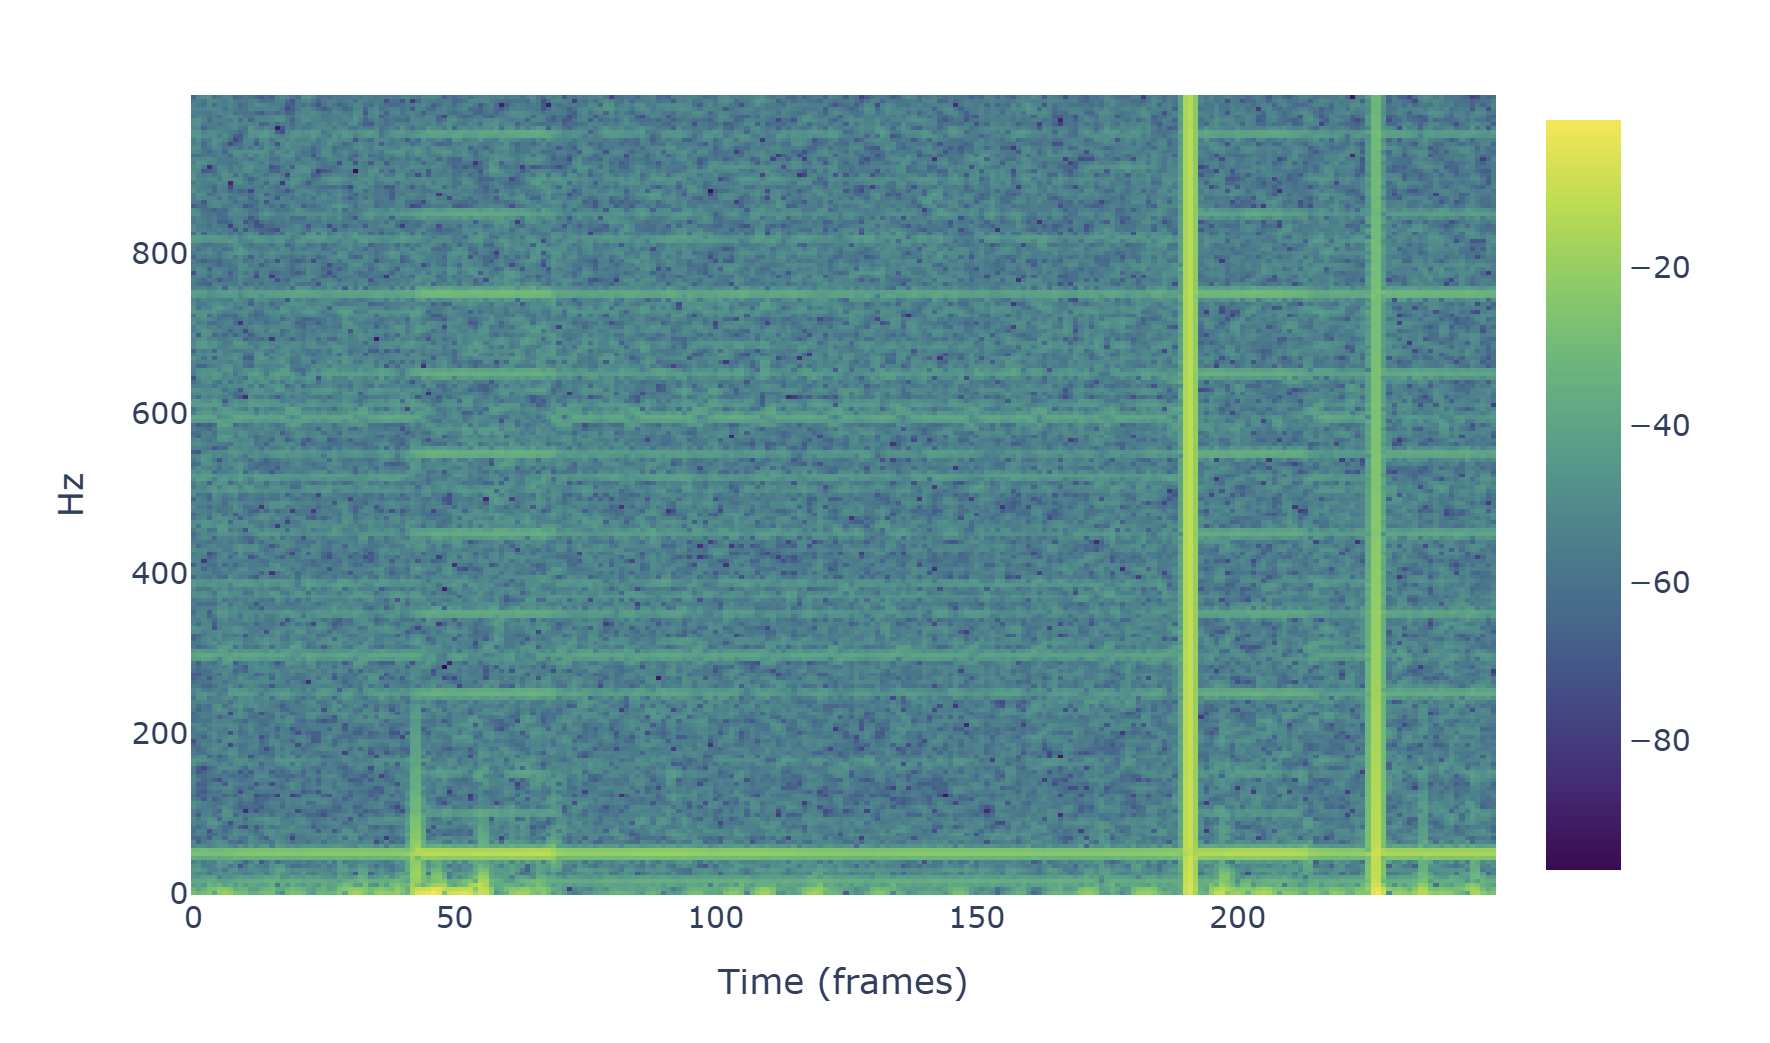

# Task 5

In [4]:
device_name = '/Dev7'

Acquired data: [0.000913, -0.000279, -0.000655, -0.000918, -0.000457, 0.000149, 0.000267, 0.000827, 0.000597, 0.001124, 0.001065, 0.000656, 0.000729, 0.000300, 0.000136, -0.000661, -0.000563, 0.000136, 0.000004, 0.000373, 0.000551, 0.000880, 0.001097, 0.000412, 0.000478, 0.000182, -0.000576, -0.000503, -0.000207, 0.000116, -0.000609, -0.000437, -0.000464, 0.000531, 0.000050, -0.000207, -0.001142, 0.000096, 0.000215, -0.000431, -0.000470, -0.000523, -0.000233, -0.000661, -0.000681, -0.000240, -0.000404, -0.001182, -0.000418, -0.000457, -0.000582, -0.001307, -0.000536, -0.000543, -0.000378, -0.000352, -0.001030, -0.000681, -0.000464, -0.000899, 0.000123, -0.000345, -0.000721, -0.000134, 0.000076, -0.000602, -0.001261, -0.001478, -0.001814, -0.002203, -0.001768, -0.001142, -0.000813, -0.000773, -0.000773, -0.000266, -0.000378, -0.000148, -0.000246, -0.000484, -0.000721, -0.001043, -0.000971, -0.001234, -0.001267, -0.001030, -0.001195, -0.001116, -0.000826, -0.000187, -0.000075, -0.000609,

Text(0.5, 0, 'sample no')

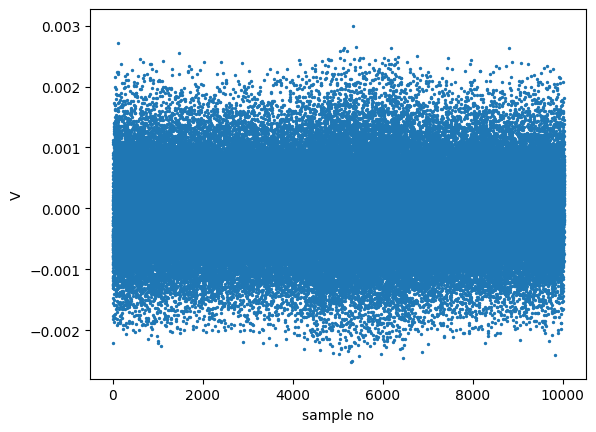

In [22]:

data = []
times = []

sample_time = 10
sample_freq = 10000
nsamples = sample_freq*sample_time

start = time.time()

sin_freq    = 100
sin_amp     = 10
sin_offset  = 0
sin_times = np.linspace(0, sample_time, nsamples)
sin_data = sin_amp * np.sin(2 * np.pi * sin_freq * sin_times) + sin_offset

''' 
'''
with nidaqmx.Task() as ai_task, nidaqmx.Task() as ao_task:
    ai_task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-0.2, max_val=0.2
    )
    ai_task.timing.cfg_samp_clk_timing(
        rate=sample_freq,
        sample_mode=AcquisitionType.CONTINUOUS,
        samps_per_chan=nsamples
    )
    ai_task.start()    

    ao_task.ao_channels.add_ao_voltage_chan(device_name+"/ao0")
    ao_task.timing.cfg_samp_clk_timing(sample_freq, sample_mode=AcquisitionType.FINITE,
        samps_per_chan=len(sin_data))
    
    ao_task.write(sin_data)

    #ao_task.start()
    data = ai_task.read(number_of_samples_per_channel=nsamples)

    end = time.time()
    times = np.linspace(0, end-start, len(data))

    print("Acquired data: [" + ", ".join(f"{value:f}" for value in data) + "]")

plt.scatter(np.linspace(0, times[-1]*1e3, len(data)), data,2)
plt.ylabel('V')
plt.xlabel("sample no")

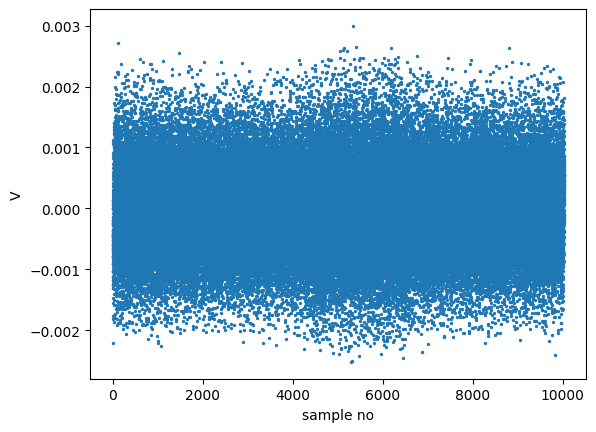

In [23]:
print(f"mean {np.mean(data):.2g} V")
print(f"peak to peak {np.max(data) - np.min(data):.2g} V")
print(f"RMS error: {np.sqrt(np.mean(np.square(np.array(data) - np.mean(sin_data)))):.2g} V")

mean -3.2e-06 V
peak to peak 0.0055 V
RMS error: 0.0007 V


| Scenario                                                                                                         | DAQ range | Mean Value | Noise level |         | Brief description on any noticeable characteristics |
|------------------------------------------------------------------------------------------------------------------|-----------|------------|-------------|---------|-----------------------------------------------------|
|                                                                                                                  | [土 V]    | V          | [V p-p]     | [V rms] |                                                     |
| Baseline -1 M resistor with no sine wave generated                                                               | .2        | -3.2e-06   | 0.0055      | 0.0007  |                                                     |
| $1 \mathrm{M} \Omega$ resistor in close proximity to 10 Vpp sine wave in unshielded cable                        | .2        | -1.7e-05   | 0.032       | 0.0032  |                                                     |
| $1 \mathrm{M} \Omega$ resistor in close proximity to 10 Vpp sine wave in shielded cable, shielding not connected | .2        | -2.4e-05   | 0.027       | 0.0016  |                                                     |
| $1 \mathrm{M} \Omega$ resistor in close proximity to 10 Vpp sine wave in shielded cable, shielding grounded      | .2        | -8.9e-06   | 0.017       | 0.004   |                                                     |
| $1 \mathrm{M} \Omega$ resistor with 10 Vpp sine wave, closeby cable section disconnected                         | .2        | -8.9e-06   | 0.017       | 0.004   |                                                     |

Q: Did the shielding effect the noise levels?

A: Yes, it greately reduced noise

Q: How did the grounding of the shield effect the results?

A: Even when not grounded it helped with reducing the noise

Q: What extra information does the scenario D provide you? How could you use this information to better analyze the results.

A: There are cables leading to the test rig. There is also some cross talk. This helps take that into account. 

# Tasks

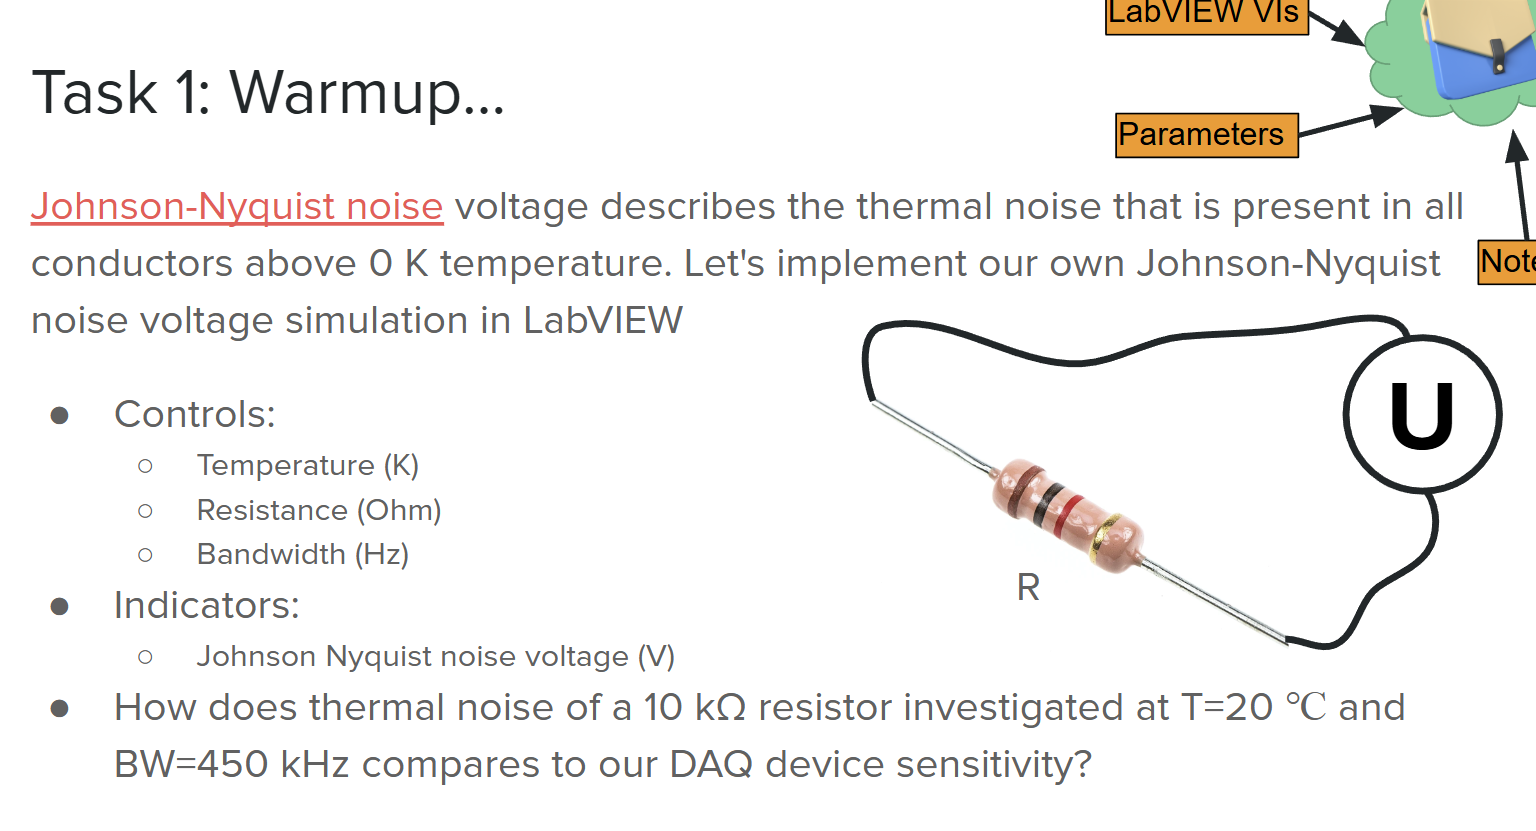

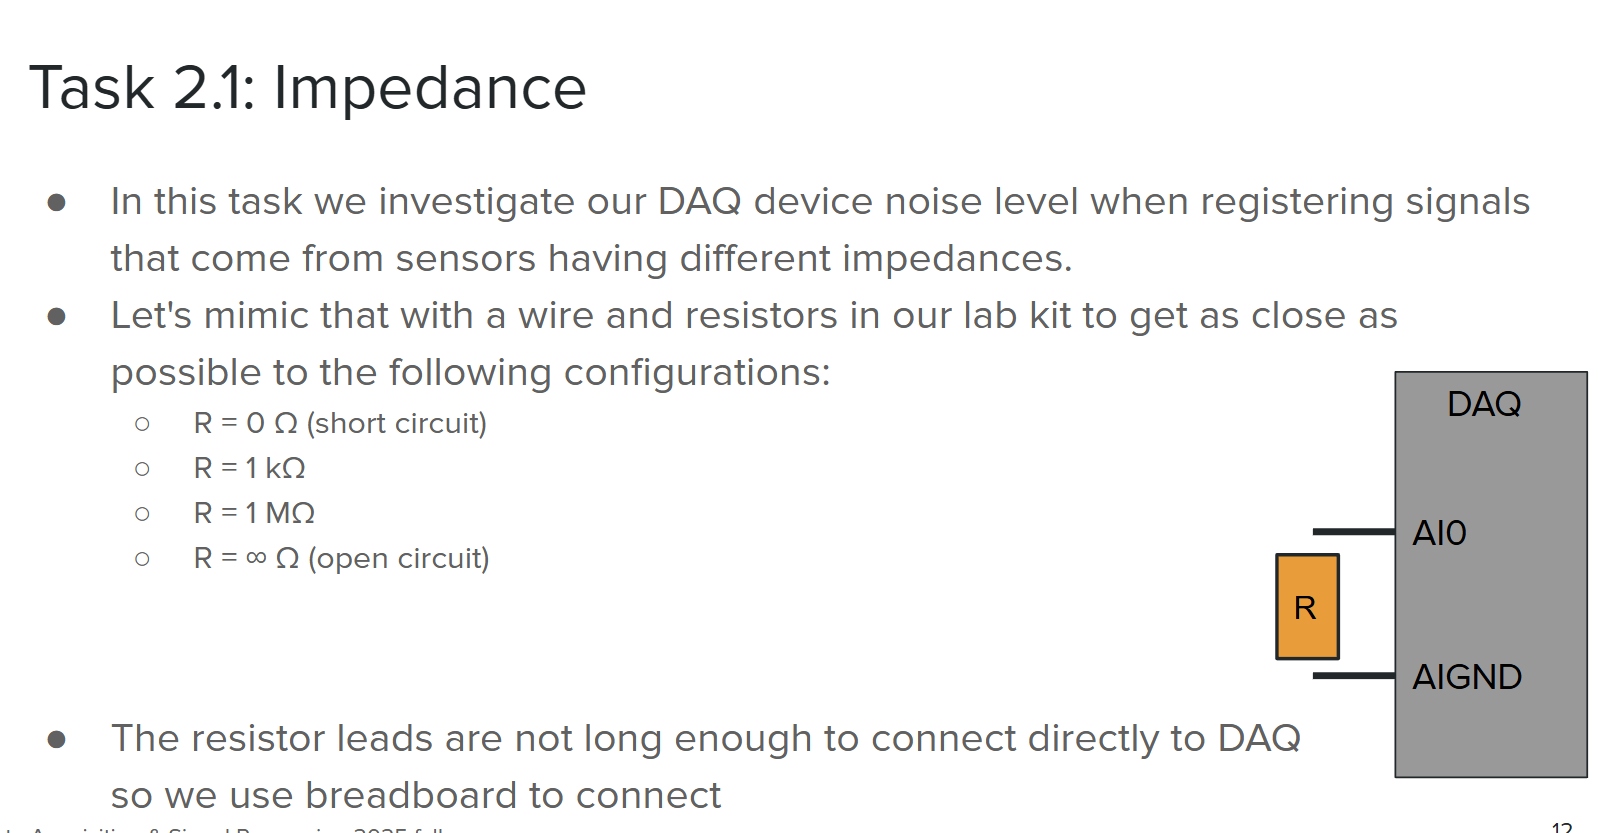
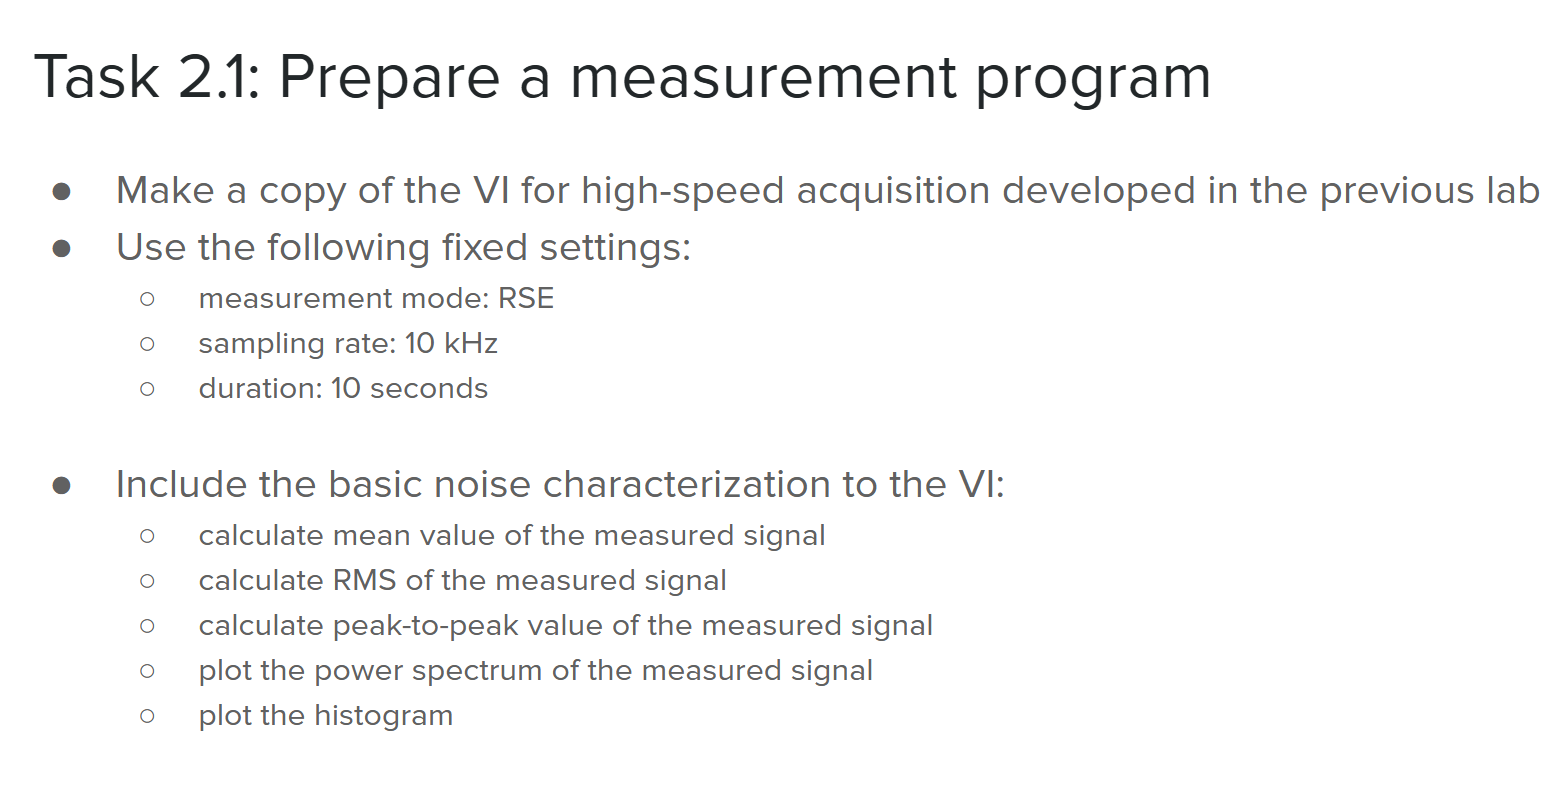
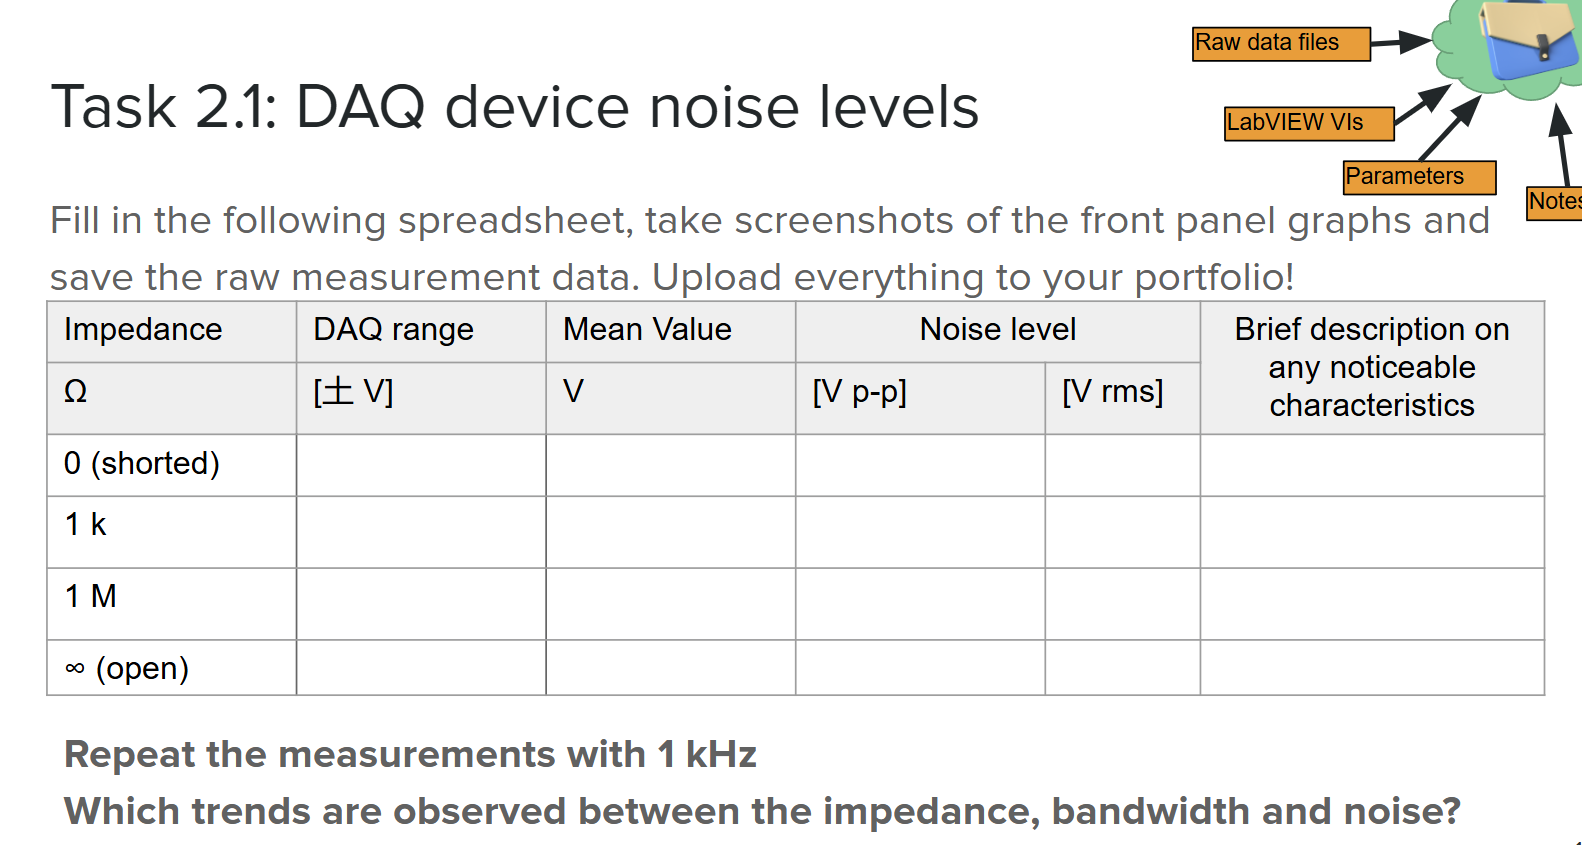

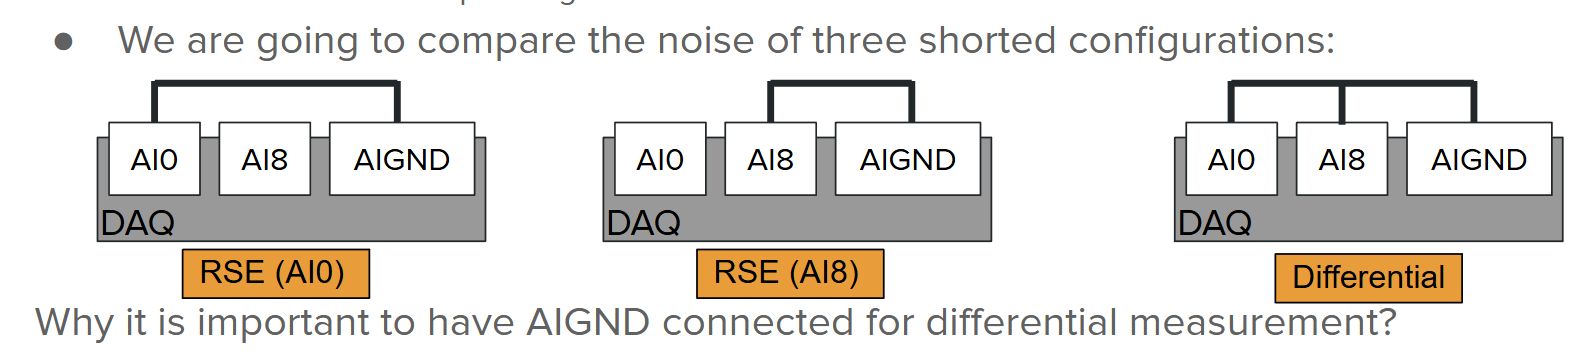
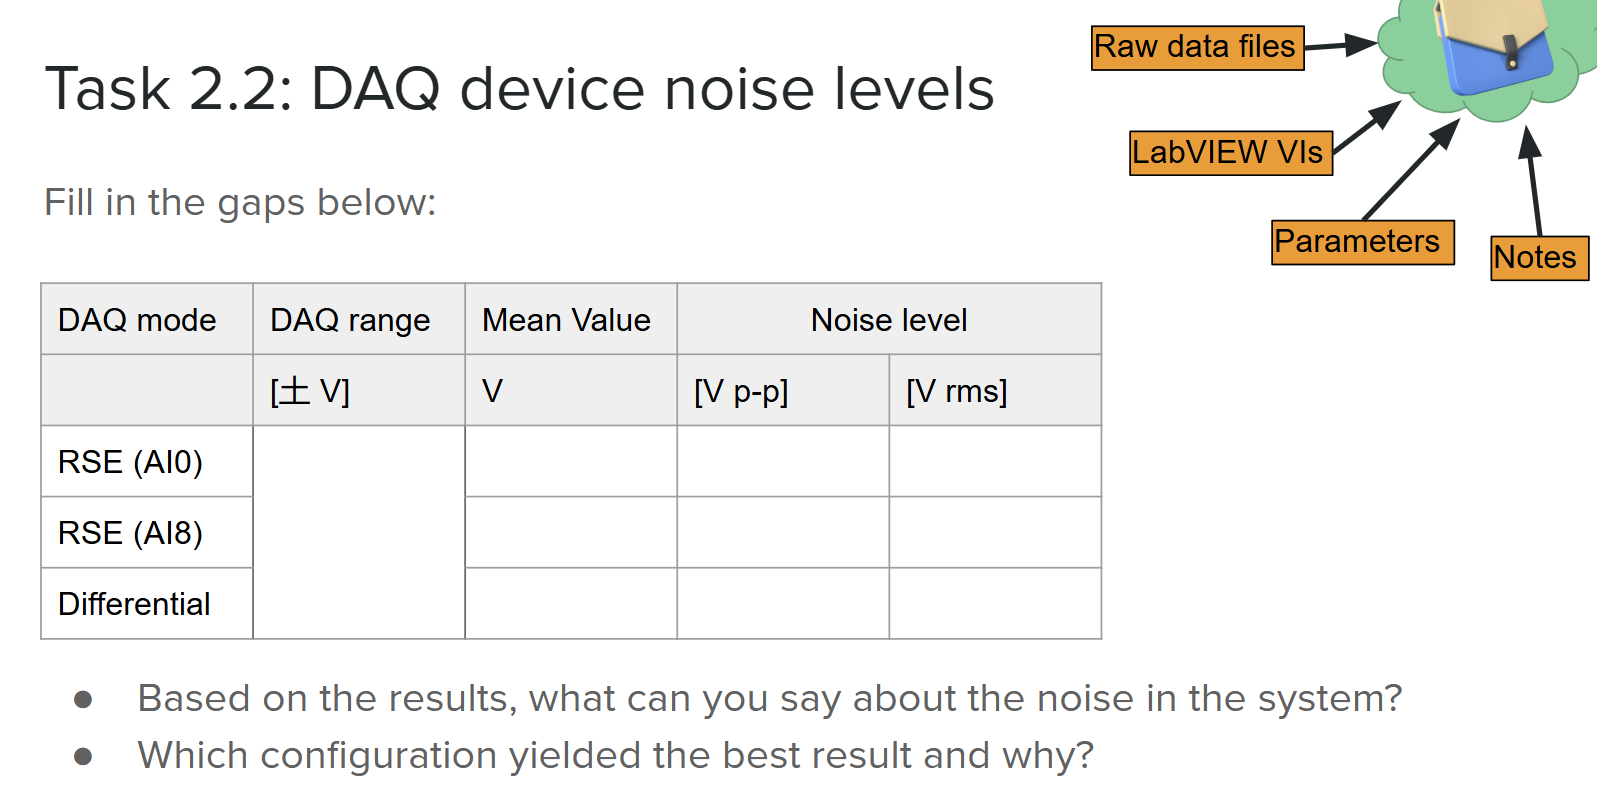

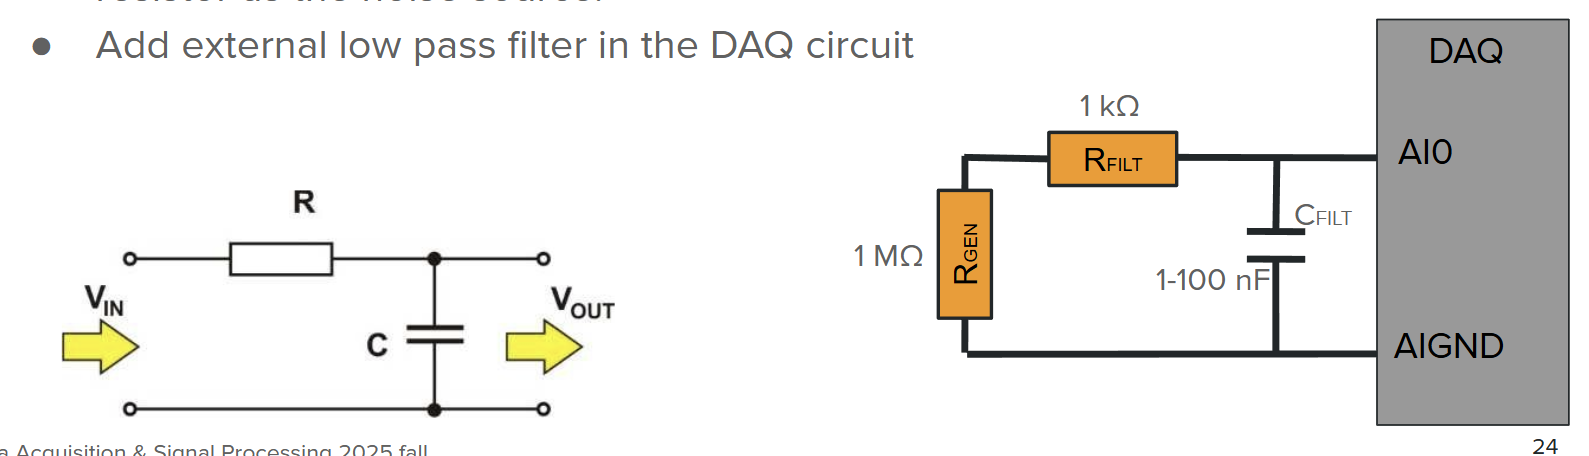

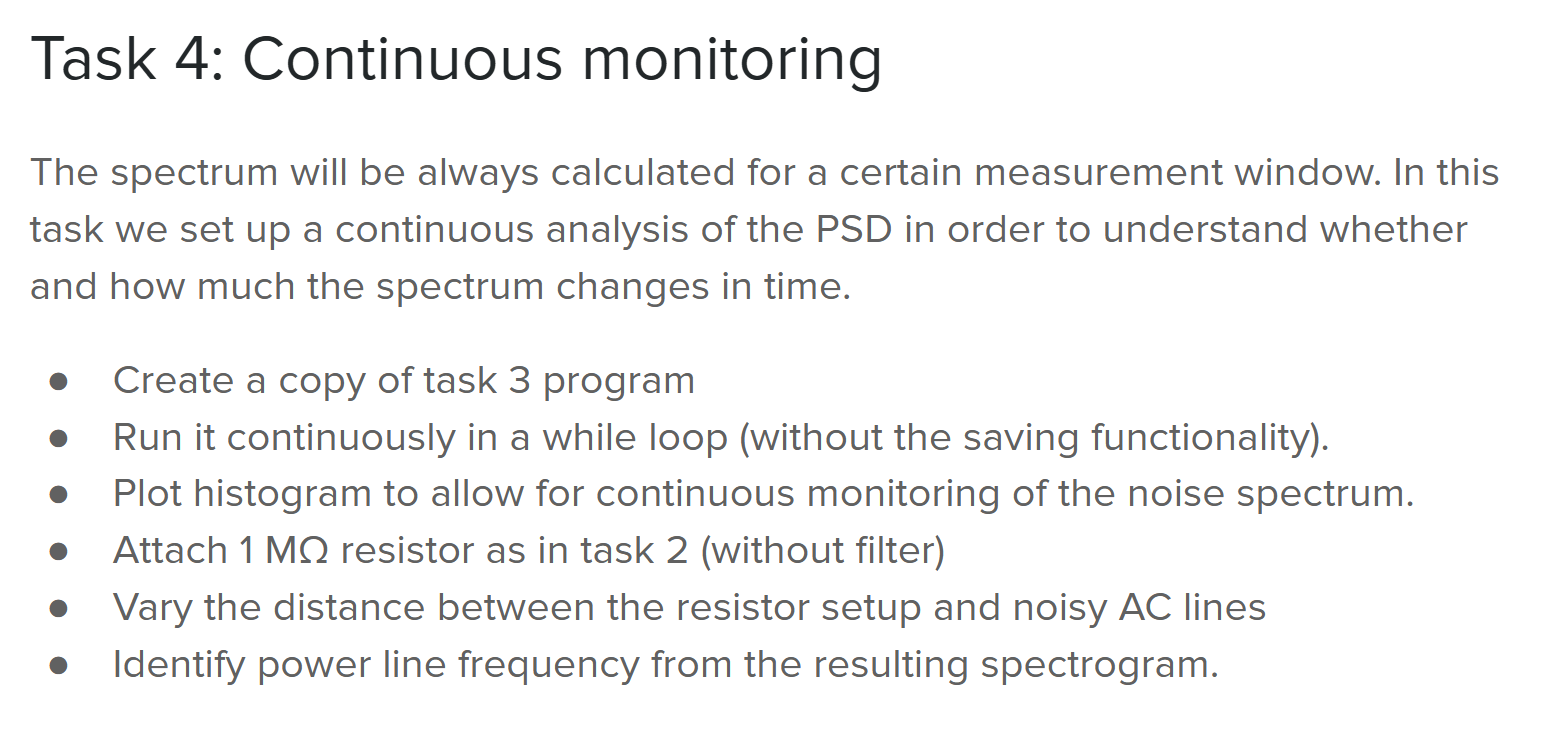

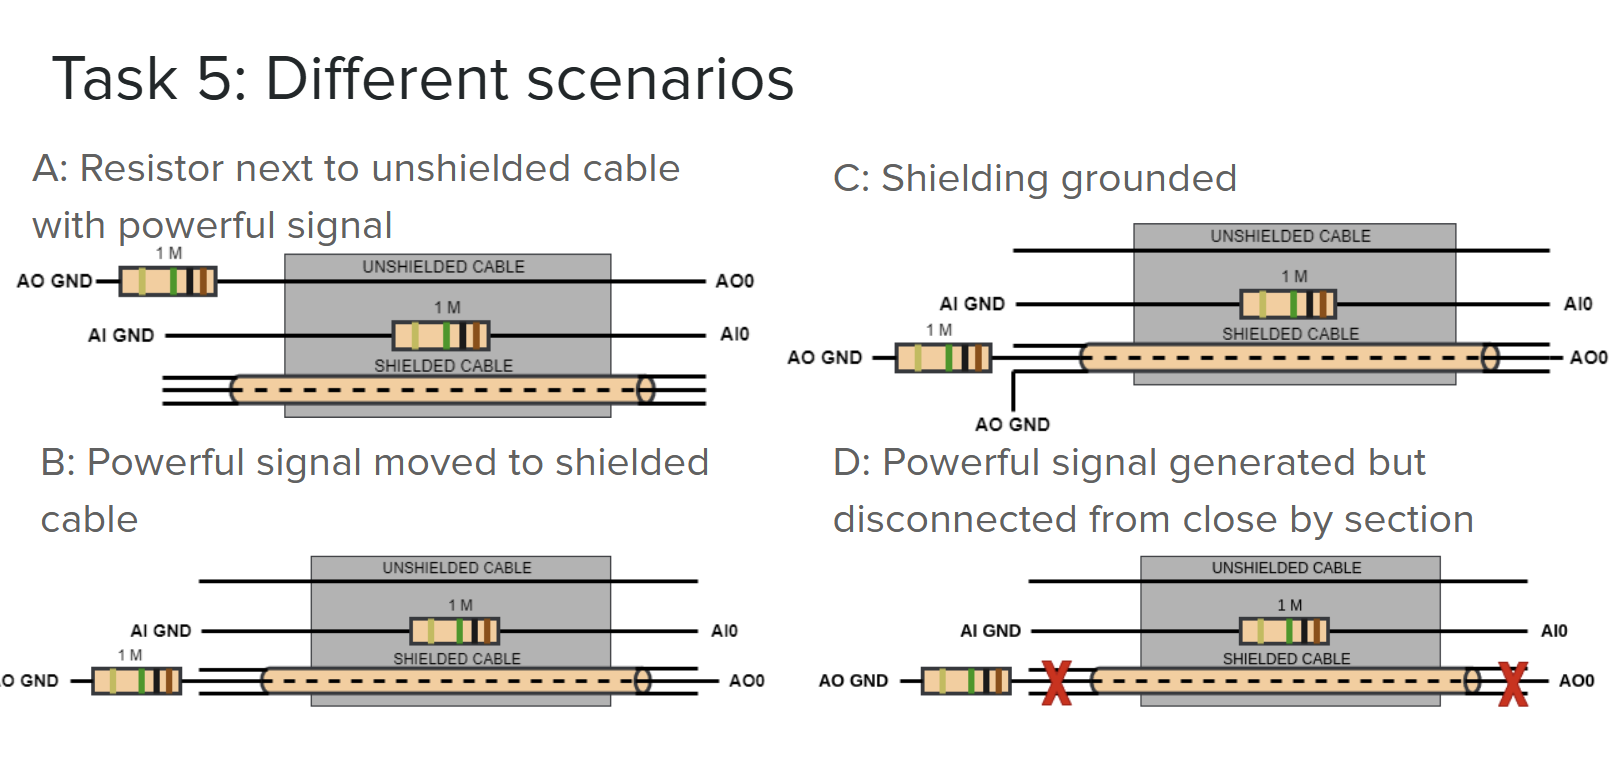